# S&P 500 Sharpe Ratio

## Data

In [1]:
from pathlib import Path
import hashlib
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from IPython.display import display

ROOT = Path.cwd()
if not (ROOT / 'data' / 'sp500_sharpe').is_dir():
    raise FileNotFoundError('Run from the notebook directory.')
DATA_DIR = ROOT / 'data' / 'sp500_sharpe'
TRADING_DAYS = 252
WINDOW = 252

plt.rcParams.update({
    'figure.dpi': 120, 'font.size': 10,
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.titleweight': 'bold', 'axes.grid': True, 'grid.alpha': 0.18,
})

metadata = json.loads((DATA_DIR / 'provenance.json').read_text())
def read_series(name):
    path = DATA_DIR / f'{name}.csv'
    digest = hashlib.sha256(path.read_bytes()).hexdigest()
    if digest != metadata['series'][name]['sha256']:
        raise ValueError(f'{name}: cached file does not match its provenance hash.')
    table = pd.read_csv(path, parse_dates=['observation_date'], na_values=['.'])
    series = table.set_index('observation_date')[name].sort_index()
    if not series.index.is_unique:
        raise ValueError(f'{name}: duplicate dates.')
    return pd.to_numeric(series, errors='raise')

price_raw = read_series('SP500')
yield_raw = read_series('DGS3MO')
price = price_raw.dropna()
yields = yield_raw.dropna()
assert len(price) > WINDOW and (price > 0).all()
assert price.index.max() <= pd.Timestamp(metadata['requested_end'])
display(pd.DataFrame({
    'series': ['SP500', 'DGS3MO'],
    'first_observation': [price.index.min().date(), yields.index.min().date()],
    'last_observation': [price.index.max().date(), yields.index.max().date()],
    'valid_observations': [len(price), len(yields)],
    'missing_rows_in_source': [price_raw.isna().sum(), yield_raw.isna().sum()],
    'frequency': ['Daily close', 'Daily annualized yield (%)'],
}))

,series,first_observation,last_observation,valid_observations,missing_rows_in_source,frequency
0,SP500,2016-09-09,2026-09-08,2512,96,Daily close
1,DGS3MO,2016-08-01,2026-09-04,2525,110,Daily annualized yield (%)


## Daily Returns

In [1]:
returns = price.pct_change(fill_method=None).dropna().rename('return')
previous_close = pd.Series(price.index[:-1], index=price.index[1:])
lookup = pd.DataFrame({'date': returns.index, 'previous_close': previous_close.to_numpy()})
rate_table = pd.DataFrame({'rf_observed_date': yields.index, 'yield_pct': yields.to_numpy()})
aligned = pd.merge_asof(
    lookup.sort_values('previous_close'), rate_table.sort_values('rf_observed_date'),
    left_on='previous_close', right_on='rf_observed_date', direction='backward',
).set_index('date')
assert aligned['yield_pct'].notna().all()
assert (aligned['rf_observed_date'] <= aligned['previous_close']).all()
assert (aligned['previous_close'] < aligned.index).all()
rate_age = (aligned.index.to_series() - aligned['rf_observed_date']).dt.days
assert rate_age.max() <= 7, 'Risk-free proxy is stale; inspect missing observations.'

result = pd.DataFrame({'SP500': price.reindex(returns.index), 'return': returns})
result['rf_observed_date'] = aligned['rf_observed_date']
result['rf_annual_pct'] = aligned['yield_pct']
result['rf_daily'] = result['rf_annual_pct'] / 100 / TRADING_DAYS
result['excess_return'] = result['return'] - result['rf_daily']
display(result.head())

NameError: name 'price' is not defined

| Column | Full name |
|---|---|
| `rf_observed_date` | Risk-Free Rate Observation Date |
| `rf_annual_pct` | Annualized Risk-Free Rate in Percent |
| `rf_daily` | Daily Risk-Free Rate |
| `excess_return` | Daily Excess Return |

## Annualized Sharpe Ratio

In [3]:
rolling_r = result['return'].rolling(WINDOW, min_periods=WINDOW)
rolling_e = result['excess_return'].rolling(WINDOW, min_periods=WINDOW)
result['mu_excess_annual'] = TRADING_DAYS * rolling_e.mean()
result['sigma_annual'] = np.sqrt(TRADING_DAYS) * rolling_r.std(ddof=1)
result['lambda_excess'] = result['mu_excess_annual'] / result['sigma_annual'].replace(0, np.nan)
result['lambda_excess_squared'] = result['lambda_excess'] ** 2
rolling = result.dropna(subset=['lambda_excess']).copy()

# Independent direct calculation for the final window and warm-up checks.
last_r = result['return'].iloc[-WINDOW:].to_numpy()
last_e = result['excess_return'].iloc[-WINDOW:].to_numpy()
np.testing.assert_allclose(rolling['lambda_excess'].iloc[-1],
                           np.sqrt(TRADING_DAYS) * last_e.mean() / last_r.std(ddof=1))
assert result['lambda_excess'].first_valid_index() == result.index[WINDOW - 1]
assert len(rolling) == len(result) - WINDOW + 1
assert np.isfinite(rolling[['lambda_excess', 'sigma_annual']]).all().all()
assert (rolling['sigma_annual'] > 0).all()
result.to_csv(DATA_DIR / 'sp500_daily_and_rolling_1y.csv', index_label='date', float_format='%.12g')
display(rolling[['mu_excess_annual', 'sigma_annual', 'lambda_excess',
                 'lambda_excess_squared']].tail().round(4))

,mu_excess_annual,sigma_annual,lambda_excess,lambda_excess_squared
observation_date,,,,
2026-09-01,0.1367,0.1279,1.0688,1.1423
2026-09-02,0.1483,0.1278,1.1605,1.3467
2026-09-03,0.1538,0.1281,1.2006,1.4414
2026-09-04,0.1417,0.1279,1.1075,1.2265
2026-09-08,0.1390,0.1280,1.0857,1.1787


| Column | Full name |
|---|---|
| `mu_excess_annual` | Annualized Mean Excess Return |
| `sigma_annual` | Annualized Return Volatility |
| `lambda_excess` | Annualized Sharpe Ratio |
| `lambda_excess_squared` | Squared Annualized Sharpe Ratio |

All four quantities are calculated over a trailing 252-trading-day window.

## Plots

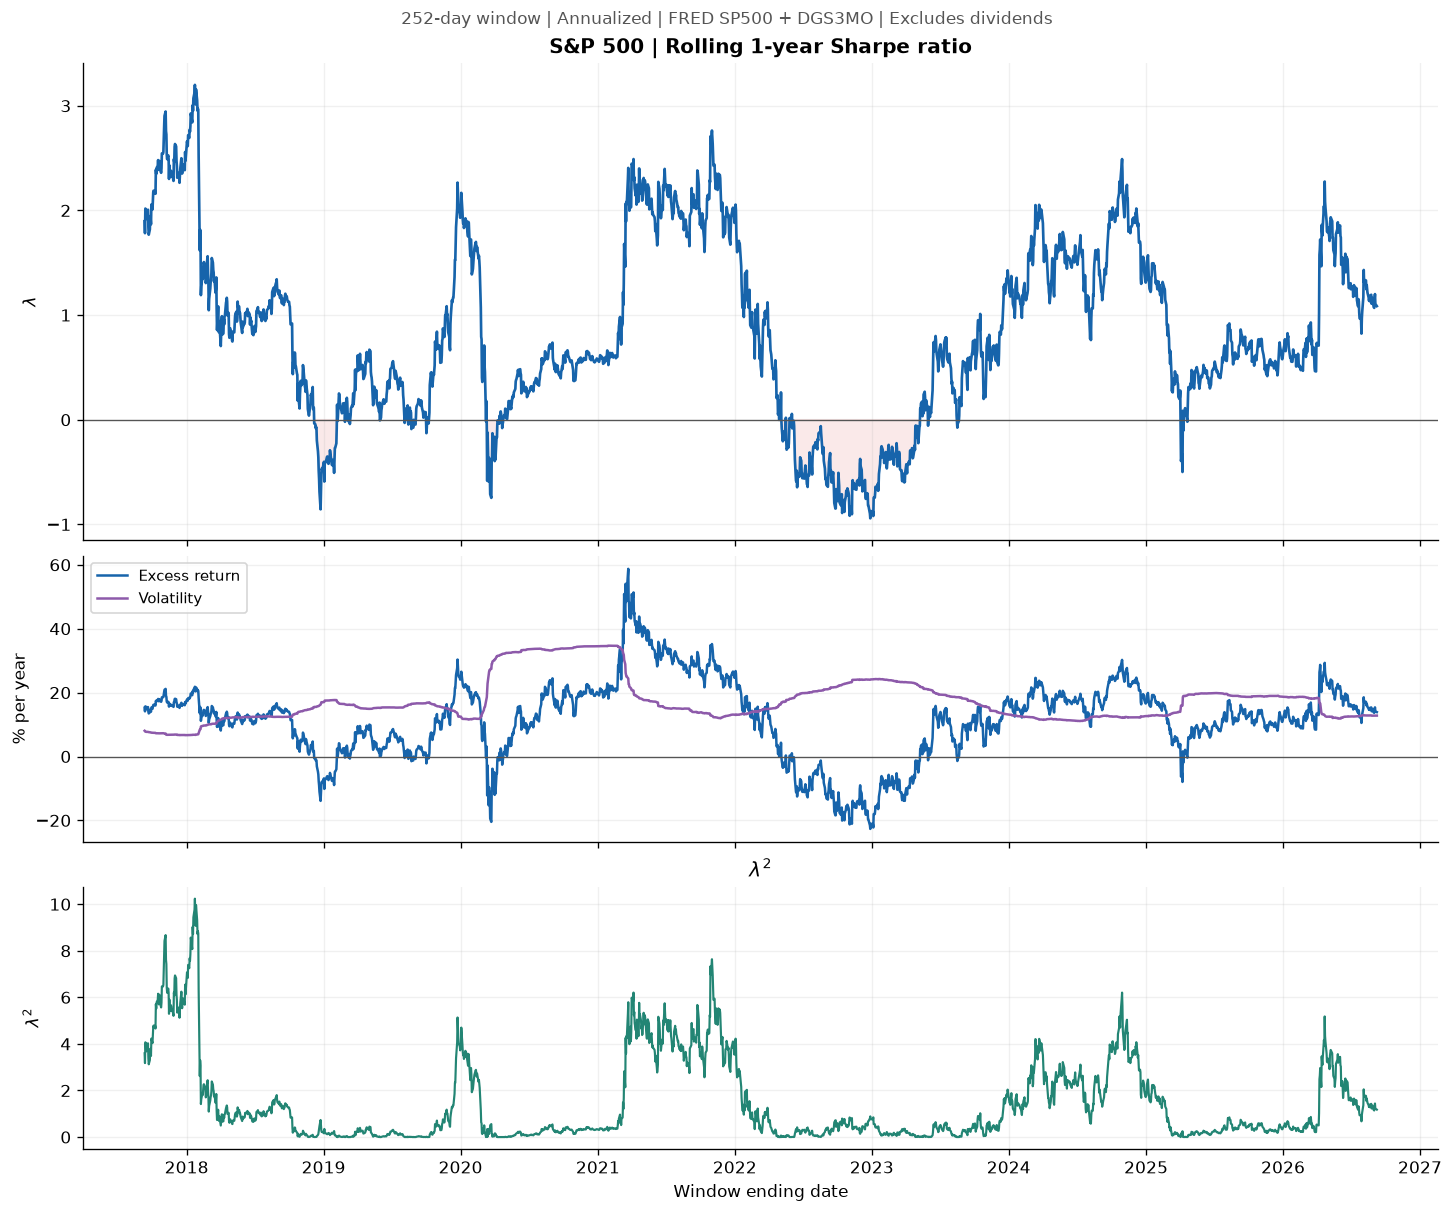

In [4]:
fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True,
                         gridspec_kw={'height_ratios': [2, 1.2, 1.1]}, layout='constrained')
x = rolling.index
axes[0].plot(x, rolling['lambda_excess'], color='#1764ab', lw=1.6,
             label=r'$\lambda$')
axes[0].axhline(0, color='#555555', lw=0.8)
axes[0].fill_between(x, rolling['lambda_excess'].to_numpy(), 0,
                    where=rolling['lambda_excess'].to_numpy() < 0, color='#d95858', alpha=0.13)
axes[0].set(title='S&P 500 | Rolling 1-year Sharpe ratio', ylabel=r'$\lambda$')
axes[1].plot(x, 100 * rolling['mu_excess_annual'], color='#1764ab', label='Excess return')
axes[1].plot(x, 100 * rolling['sigma_annual'], color='#8d5aaa', label='Volatility')
axes[1].axhline(0, color='#555555', lw=0.8)
axes[1].set(ylabel='% per year')
axes[1].legend(loc='upper left', fontsize=9)
axes[2].plot(x, rolling['lambda_excess_squared'], color='#238574', lw=1.3)
axes[2].set(ylabel=r'$\lambda^2$', xlabel='Window ending date',
            title=r'$\lambda^2$')
axes[2].xaxis.set_major_locator(mdates.YearLocator())
axes[2].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
fig.suptitle('252-day window | Annualized | FRED SP500 + DGS3MO | Excludes dividends',
             fontsize=10, color='#555555')
plt.show()